# Reproduction of the Contrastive NCM detector

Detector-only reproduction of Kuppa & Le-Khac. Experiments include: 
1. drift detection with held-out classes (normal drift)
2. robustness to instance-based PGD poisoning (adversarial drift).

## Imports and configuration

In [ ]:
import os
import sys
from concurrent.futures import ThreadPoolExecutor

sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from src.detectors.contrastive_ncm import (
    ContrastiveNCMDetector,
    DriftAutoencoder,
    NCMClassifier,
    train_plain_autoencoder,
)

DATA_DIR = os.path.abspath('../../data/CICIDS2017_Engelen')
EPOCHS = 300
LR = 0.0001
BATCH_SIZE = 4096
TEST_SIZE = 0.25
RANDOM_SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_float32_matmul_precision('high')

N_RUNS = 5
N_DROP = 2

DROPPED_CLASSES = ['DoS', 'Patator']
SURROGATE_EPOCHS = 300
PGD_EPSILON = 0.3
PGD_ALPHA = 0.01
PGD_STEPS = 20
N_BAGS = 5
INJECTION_RATIOS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]


from src.experiments.contrastive_ncm import set_progress
PROGRESS = False
set_progress(PROGRESS)

/home/azureuser/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load and preprocess

In [ ]:
DAY_FILES = [
    'Monday-WorkingHours.csv',
    'Tuesday-WorkingHours.csv',
    'Wednesday-WorkingHours.csv',
    'Thursday-WorkingHours.csv',
    'Friday-WorkingHours.csv',
]

print('Loading data...')
df = pd.concat(
    [pd.read_csv(os.path.join(DATA_DIR, f)) for f in DAY_FILES],
    ignore_index=True,
)
print(f'Total rows: {len(df):,}')

df.drop(
    columns=['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Timestamp'],
    inplace=True,
    errors='ignore',
)
df['Label'] = df['Label'].apply(lambda x: 'BENIGN' if x.endswith('- Attempted') else x)
df['Label'] = df['Label'].replace(
    {
        'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS',
        'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'FTP-Patator': 'Patator',
        'SSH-Patator': 'Patator',
    }
)

X_raw = df[[c for c in df.columns if c != 'Label']].copy()
y_str = df['Label'].values
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_raw.dropna(axis=1, how='all', inplace=True)
X_raw.fillna(X_raw.mean(), inplace=True)

X = StandardScaler().fit_transform(X_raw).astype(np.float32)
le_full = LabelEncoder()
y_all = le_full.fit_transform(y_str)

input_dim = X.shape[1]
print(f'Features: {input_dim}\nClasses: {list(le_full.classes_)}')


Loading data...


Total rows: 2,100,814


Features: 77
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'Patator', 'PortScan', 'Web Attack']


## 1. Normal drift

In [ ]:
class GPUDataLoader:
    def __init__(self, X: torch.Tensor, y: torch.Tensor, batch_size: int, shuffle: bool = True):
        self.X, self.y, self.batch_size, self.n = X, y, batch_size, X.shape[0]
        self.shuffle = shuffle

    def __len__(self) -> int:
        return (self.n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        idx = (
            torch.randperm(self.n, device=self.X.device)
            if self.shuffle
            else torch.arange(self.n, device=self.X.device)
        )
        for i in range(0, self.n, self.batch_size):
            b = idx[i : i + self.batch_size]
            yield self.X[b], self.y[b]


def make_loader(X_arr, y_arr, shuffle=True):
    return GPUDataLoader(
        torch.from_numpy(X_arr).to(DEVICE),
        torch.from_numpy(y_arr).to(DEVICE),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
    )


def best_threshold(cal_dists, val_dists, val_labels, n_steps=300):
    best_f1, best_t, best_q = 0.0, 0.0, 0.0
    for q in np.linspace(0.01, 0.99, n_steps):
        t = float(torch.quantile(cal_dists, q).item())
        preds = (val_dists > t).numpy().astype(int)

        f1 = f1_score(val_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t, best_q = f1, t, q

    return best_t, best_q * 100


def evaluate(dists, y_true, threshold):
    preds = (dists > threshold).numpy().astype(int)
    return (
        precision_score(y_true, preds, zero_division=0),
        recall_score(y_true, preds, zero_division=0),
        f1_score(y_true, preds, zero_division=0),
    )


def run_experiment(dropped_classes):
    d_ids = np.array([le_full.transform([c])[0] for c in dropped_classes])

    X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
        X, y_all, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_all
    )
    mask_r = ~np.isin(y_tr_r, d_ids)
    le_r = LabelEncoder()
    y_tr_enc = le_r.fit_transform(y_tr_r[mask_r]).astype(np.int64)
    n_classes_r = len(le_r.classes_)

    X_fit_r, X_cal_r, y_fit_r, _ = train_test_split(
        X_tr_r[mask_r],
        y_tr_enc,
        test_size=0.10,
        random_state=RANDOM_SEED,
        stratify=y_tr_enc,
    )

    rng_r = np.random.default_rng(RANDOM_SEED)
    pos_idx = np.where(np.isin(y_te_r, d_ids))[0]
    neg_idx = np.where(~np.isin(y_te_r, d_ids))[0]
    bal_idx = np.concatenate([pos_idx, rng_r.choice(neg_idx, size=len(pos_idx), replace=False)])
    y_bin_r = np.isin(y_te_r[bal_idx], d_ids).astype(int)

    val_r, held_r = train_test_split(
        np.arange(len(bal_idx)), test_size=0.5, random_state=RANDOM_SEED, stratify=y_bin_r
    )

    X_val_r = torch.from_numpy(X_te_r[bal_idx][val_r])
    y_val_r = y_bin_r[val_r]
    X_held_r = torch.from_numpy(X_te_r[bal_idx][held_r])
    y_held_r = y_bin_r[held_r]
    X_cal_r = torch.from_numpy(X_cal_r)

    loader_r = make_loader(X_fit_r, y_fit_r)
    det_r = ContrastiveNCMDetector(
        input_dim=input_dim, hidden_dim=64, latent_dim=32, concept_threshold=3.5, device=DEVICE
    )
    ae_r = DriftAutoencoder(input_dim=input_dim, hidden_dim=64, latent_dim=32).to(DEVICE)

    if DEVICE.type == 'cuda':
        stream_c, stream_p = torch.cuda.Stream(), torch.cuda.Stream()

        def _c():
            with torch.cuda.stream(stream_c):
                det_r.fit(loader_r, epochs=EPOCHS, lr=LR, num_classes=n_classes_r, tqdm_position=0)

        def _p():
            with torch.cuda.stream(stream_p):
                train_plain_autoencoder(ae_r, loader_r, epochs=EPOCHS, lr=LR, tqdm_position=1)

        with ThreadPoolExecutor(max_workers=2) as ex:
            fc, fp = ex.submit(_c), ex.submit(_p)
            fc.result()
            fp.result()
        torch.cuda.synchronize()
    else:
        det_r.fit(loader_r, epochs=EPOCHS, lr=LR, num_classes=n_classes_r, tqdm_position=0)
        train_plain_autoencoder(ae_r, loader_r, epochs=EPOCHS, lr=LR, tqdm_position=1)

    ae_r.eval()
    all_h, all_y = [], []
    with torch.no_grad():
        for xb, yb in loader_r:
            all_h.append(ae_r.encode(xb))
            all_y.append(yb)

    ncm_r = NCMClassifier(lambda_1=0.1)
    ncm_r.fit(torch.cat(all_h), torch.cat(all_y), n_classes_r)

    with torch.no_grad():
        h_held_e = ae_r.encode(X_held_r.to(DEVICE)).cpu()

    ed_held = torch.cdist(h_held_e, ncm_r.prototypes.cpu()).min(dim=1).values

    _, _, cd_c = det_r.detect(X_cal_r)
    _, _, vd_c = det_r.detect(X_val_r)
    _, _, td_c = det_r.detect(X_held_r)

    with torch.no_grad():
        cd_p = ncm_r._compute_distance(ae_r.encode(X_cal_r.to(DEVICE))).min(dim=1).values.cpu()
        vd_p = ncm_r._compute_distance(ae_r.encode(X_val_r.to(DEVICE))).min(dim=1).values.cpu()
        td_p = ncm_r._compute_distance(ae_r.encode(X_held_r.to(DEVICE))).min(dim=1).values.cpu()

    thresh_c, pct_c = best_threshold(cd_c, vd_c, y_val_r)
    thresh_p, pct_p = best_threshold(cd_p, vd_p, y_val_r)

    precision_c, recall_c, f1_c = evaluate(td_c, y_held_r, thresh_c)
    precision_p, recall_p, f1_p = evaluate(td_p, y_held_r, thresh_p)

    print(
        f'ContrastiveNCM  precision={precision_c:.3f}  recall_c={recall_c:.3f}  f1={f1_c:.3f}   (thresh@{pct_c:.0f}%)'
    )
    print(
        f'Plain AE NCM    precision={precision_p:.3f}  recall_p={recall_p:.3f}  f1={f1_p:.3f}   (thresh@{pct_p:.0f}%)'
    )

    return {
        'ContrastiveNCM': (precision_c, recall_c, f1_c, pct_c),
        'Plain AE NCM': (precision_p, recall_p, f1_p, pct_p),
        '_auroc': {
            'ContrastiveNCM': roc_auc_score(y_held_r, td_c.numpy()) * 100,
            'Plain AE NCM': roc_auc_score(y_held_r, td_p.numpy()) * 100,
            'Euclidean': roc_auc_score(y_held_r, ed_held.numpy()) * 100,
        },
    }


In [ ]:
ATTACK_CLASSES = [c for c in le_full.classes_ if c != 'BENIGN']

rng_runs = np.random.default_rng(0)
run_dropped = [
    list(rng_runs.choice(ATTACK_CLASSES, size=N_DROP, replace=False)) for _ in range(N_RUNS)
]

print('Run  Dropped classes')
for i, dropped in enumerate(run_dropped):
    print(f'{i+1}  {dropped}')

all_results = []
for i, dropped in enumerate(run_dropped):
    print(f'\nRun {i+1}/{N_RUNS}  dropped={dropped}')
    all_results.append(run_experiment(dropped))

prf_methods = [k for k in all_results[0] if not k.startswith('_')]
print('\n' + '=' * 70)
print(f"{'Method':<22} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Thresh%':>9}")
print('=' * 70)

for method in prf_methods:
    ps = np.mean([r[method][0] for r in all_results])
    rs = np.mean([r[method][1] for r in all_results])
    fs = np.mean([r[method][2] for r in all_results])
    pcts = np.mean([r[method][3] for r in all_results])
    print(f'{method:<22} {ps:>10.3f} {rs:>10.3f} {fs:>10.3f} {pcts:>8.1f}%')

print('=' * 70)

print('\n' + '=' * 45)
print(f"{'Method':<20} {'AUROC':>8}   {'Paper':>6}")
paper_auroc = {'ContrastiveNCM': 89.8, 'Euclidean': 52.3, 'Plain AE NCM': None}
print('=' * 45)

for method in ['ContrastiveNCM', 'Plain AE NCM', 'Euclidean']:
    vals = np.mean([r['_auroc'][method] for r in all_results])
    paper = f"{paper_auroc[method]:.1f}" if paper_auroc[method] else '  —'
    print(f'{method:<20} {vals:>8.1f}   {paper:>6}')

print('=' * 45)


Run  Dropped classes
1  [np.str_('Patator'), np.str_('Web Attack')]
2  [np.str_('DoS'), np.str_('DDoS')]
3  [np.str_('Web Attack'), np.str_('Bot')]
4  [np.str_('Patator'), np.str_('Web Attack')]
5  [np.str_('Heartbleed'), np.str_('Infiltration')]

Run 1/5  dropped=[np.str_('Patator'), np.str_('Web Attack')]


    [Plain AE 20/300] loss=0.0661


    [Contrastive 20/300] loss=0.1360


    [Plain AE 40/300] loss=0.0310


    [Contrastive 40/300] loss=0.0794


...

    [Plain AE 280/300] loss=0.0032


    [Contrastive 280/300] loss=0.0231


    [Plain AE 300/300] loss=0.0031


    [Contrastive 300/300] loss=0.0223


ContrastiveNCM  precision=0.833  recall_c=1.000  f1=0.909   (thresh@89%)
Plain AE NCM    precision=0.714  recall_p=1.000  f1=0.833   (thresh@55%)

Method                  Precision     Recall         F1   Thresh%
ContrastiveNCM              0.815      0.979      0.887     78.7%
Plain AE NCM                0.666      0.979      0.788     46.4%

Method                  AUROC    Paper
ContrastiveNCM           85.1     89.8
Plain AE NCM             61.9        —
Euclidean                75.8     52.3


## 2. Adversarial drift

In [ ]:
dropped_ids = np.array([le_full.transform([c])[0] for c in DROPPED_CLASSES])

X_tr_raw, X_te, y_tr_raw, y_te = train_test_split(
    X, y_all, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_all
)

train_known_mask = ~np.isin(y_tr_raw, dropped_ids)
X_tr_known = X_tr_raw[train_known_mask]
y_tr_known_orig = y_tr_raw[train_known_mask]

le_train = LabelEncoder()
y_tr_reenc = le_train.fit_transform(y_tr_known_orig).astype(np.int64)
n_classes = len(le_train.classes_)

X_fit, X_cal_arr, y_fit, _ = train_test_split(
    X_tr_known,
    y_tr_reenc,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_tr_reenc,
)
X_cal = torch.from_numpy(X_cal_arr)

X_tr_novel = X_tr_raw[~train_known_mask]

rng = np.random.default_rng(RANDOM_SEED)
pos_idx = np.where(np.isin(y_te, dropped_ids))[0]
neg_idx = np.where(~np.isin(y_te, dropped_ids))[0]
bal_idx = np.concatenate([pos_idx, rng.choice(neg_idx, size=len(pos_idx), replace=False)])
y_bin = np.isin(y_te[bal_idx], dropped_ids).astype(int)

val_idx, held_idx = train_test_split(
    np.arange(len(bal_idx)), test_size=0.5, random_state=RANDOM_SEED, stratify=y_bin
)
X_val = torch.from_numpy(X_te[bal_idx][val_idx])
y_val = y_bin[val_idx]
X_held = torch.from_numpy(X_te[bal_idx][held_idx])
y_held = y_bin[held_idx]

print(f'Dropped classes     : {DROPPED_CLASSES}')
print(f'Training classes    : {n_classes}  -> {[le_full.classes_[i] for i in le_train.classes_]}')
print(f'Fit samples         : {len(X_fit):,}')
print(f'Calibration samples : {len(X_cal_arr):,}')
print(f'Novel train pool    : {len(X_tr_novel):,}  (attacker poison pool)')
print(f'Val samples         : {len(X_val):,}  (balanced)')
print(f'Held-out samples    : {len(X_held):,}  (balanced)')


Dropped classes  : ['DoS', 'Patator']
Training classes : 7  -> ['BENIGN', 'Bot', 'DDoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']
Fit samples      : 1,297,404
Calibration      : 144,157
Novel train pool : 134,049  (attacker poison pool)
Val samples      : 44,683  (balanced)
Held-out samples : 44,683  (balanced)


In [ ]:
class SurrogateMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


surrogate = SurrogateMLP(input_dim, n_classes).to(DEVICE)
surrogate_opt = torch.optim.Adam(surrogate.parameters(), lr=LR)
ce_loss = nn.CrossEntropyLoss()

print('Training surrogate...')
surrogate_loader = make_loader(X_fit, y_fit)

surrogate.train()
for epoch in range(SURROGATE_EPOCHS):
    epoch_loss = 0.0
    for x_b, y_b in surrogate_loader:
        surrogate_opt.zero_grad()

        loss = ce_loss(surrogate(x_b), y_b)
        loss.backward()

        surrogate_opt.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 25 == 0 or epoch == 0 or epoch == SURROGATE_EPOCHS - 1:
        print(f'  epoch {epoch+1}/{SURROGATE_EPOCHS}  loss={epoch_loss/len(surrogate_loader):.4f}')

surrogate.eval()
print('Surrogate ready\n')

MAX_POOL = 10000
rng_pool = np.random.RandomState(RANDOM_SEED)
pool_idx = rng_pool.choice(len(X_tr_novel), size=min(MAX_POOL, len(X_tr_novel)), replace=False)
X_novel_pool = X_tr_novel[pool_idx]
print(f'Novel pool: {len(X_novel_pool):,} samples (subsampled from {len(X_tr_novel):,})\n')

centroids = np.stack([X_fit[y_fit == c].mean(axis=0) for c in range(n_classes)])
dists_c = np.linalg.norm(X_novel_pool[:, None, :] - centroids[None, :, :], axis=2)
poison_targets = dists_c.argmin(axis=1)


def pgd_generate(model, X, targets, eps, alpha, n_steps, batch_size, device):
    model.eval()
    X_adv = torch.from_numpy(X.copy()).to(device)
    X_orig = X_adv.clone()
    t = torch.from_numpy(targets).long().to(device)
    x_min = float(X_orig.min().item())
    x_max = float(X_orig.max().item())

    print(f'PGD start: {len(X_adv):,} samples  {n_steps} steps  batch={batch_size}', flush=True)
    for step in range(n_steps):
        for i in range(0, len(X_adv), batch_size):
            xb = X_adv[i : i + batch_size].clone().requires_grad_(True)
            tb = t[i : i + batch_size]

            model.zero_grad()

            loss = ce_loss(model(xb), tb)
            loss.backward()
            
            with torch.no_grad():
                xb_new = xb - alpha * xb.grad.sign()
                xb_new = torch.clamp(
                    xb_new, X_orig[i : i + batch_size] - eps, X_orig[i : i + batch_size] + eps
                )
                xb_new = xb_new.clamp(x_min, x_max)
                X_adv[i : i + batch_size] = xb_new

        print(f'step {step + 1}/{n_steps}', flush=True)

    return X_adv.cpu().numpy()


print('Generating adversarial pool...')
X_tr_novel_adv = pgd_generate(
    surrogate,
    X_novel_pool,
    poison_targets,
    eps=PGD_EPSILON,
    alpha=PGD_ALPHA,
    n_steps=PGD_STEPS,
    batch_size=BATCH_SIZE,
    device=DEVICE,
)
print('\nPoison pool ready')


Training surrogate...


  epoch 1/300  loss=0.8738


  epoch 25/300  loss=0.0167


  epoch 50/300  loss=0.0149


  epoch 75/300  loss=0.0145


...

step 17/20


step 18/20


step 19/20


step 20/20



Poison pool ready


In [ ]:
def inject_poison(X_fit, y_fit, X_adv, y_adv_labels, l_inst, n_bags=N_BAGS, seed=RANDOM_SEED):
    if l_inst == 0.0:
        return X_fit.copy(), y_fit.copy()

    rng = np.random.RandomState(seed)
    n_total = int(l_inst * len(X_fit))
    n_per_bag = max(1, n_total // n_bags)
    bags_X, bags_y = [], []

    for bag_idx in np.array_split(np.arange(len(X_fit)), n_bags):
        bX = X_fit[bag_idx]
        by = y_fit[bag_idx]
        chosen = rng.choice(len(X_adv), size=n_per_bag, replace=True)

        bags_X.append(np.vstack([bX, X_adv[chosen]]))
        bags_y.append(np.concatenate([by, y_adv_labels[chosen]]))

    return np.vstack(bags_X), np.concatenate(bags_y)

n_example = int(0.05 * len(X_fit))
print(
    f'At L_inst=0.05: ~{n_example:,} adversarial samples injected into {len(X_fit):,} training samples ({100*n_example/(len(X_fit)+n_example):.1f}% of total)'
)


At L_inst=0.05: ~64,870 adversarial samples injected into 1,297,404 training samples (4.8% of total)


In [ ]:
results = []

for l_inst in INJECTION_RATIOS:
    n_injected = int(l_inst * len(X_fit))
    print(f'\nL_inst={l_inst:.2f}  ({n_injected:,} adversarial samples injected)')

    X_poisoned, y_poisoned = inject_poison(X_fit, y_fit, X_tr_novel_adv, poison_targets, l_inst)
    poisoned_loader = make_loader(X_poisoned, y_poisoned.astype(np.int64))

    det = ContrastiveNCMDetector(
        input_dim=input_dim,
        hidden_dim=64,
        latent_dim=32,
        concept_threshold=3.5,
        device=DEVICE,
    )
    ae = DriftAutoencoder(input_dim=input_dim, hidden_dim=64, latent_dim=32).to(DEVICE)

    if DEVICE.type == 'cuda':
        stream_c, stream_p = torch.cuda.Stream(), torch.cuda.Stream()

        def _c():
            with torch.cuda.stream(stream_c):
                det.fit(
                    poisoned_loader,
                    epochs=EPOCHS,
                    lr=LR,
                    num_classes=n_classes,
                    tqdm_position=0,
                    desc_prefix=f'L={l_inst:.2f} ',
                )

        def _p():
            with torch.cuda.stream(stream_p):
                train_plain_autoencoder(
                    ae,
                    poisoned_loader,
                    epochs=EPOCHS,
                    lr=LR,
                    tqdm_position=1,
                    desc_prefix=f'L={l_inst:.2f} ',
                )

        with ThreadPoolExecutor(max_workers=2) as ex:
            fc, fp = ex.submit(_c), ex.submit(_p)
            fc.result()
            fp.result()

        torch.cuda.synchronize()
    else:
        det.fit(poisoned_loader, epochs=EPOCHS, lr=LR, num_classes=n_classes, tqdm_position=0)
        train_plain_autoencoder(ae, poisoned_loader, epochs=EPOCHS, lr=LR, tqdm_position=1)

    ae.eval()
    all_h, all_y = [], []
    with torch.no_grad():
        for x_b, y_b in poisoned_loader:
            all_h.append(ae.encode(x_b))
            all_y.append(y_b)

    ncm_p = NCMClassifier(lambda_1=0.1)
    ncm_p.fit(torch.cat(all_h), torch.cat(all_y), n_classes)

    _, _, cd_c = det.detect(X_cal)
    _, _, vd_c = det.detect(X_val)
    thresh_c, pct_c = best_threshold(cd_c, vd_c, y_val)

    with torch.no_grad():
        cd_p = ncm_p._compute_distance(ae.encode(X_cal.to(DEVICE))).min(dim=1).values.cpu()
        vd_p = ncm_p._compute_distance(ae.encode(X_val.to(DEVICE))).min(dim=1).values.cpu()

    thresh_p, pct_p = best_threshold(cd_p, vd_p, y_val)

    _, _, td_c = det.detect(X_held)
    with torch.no_grad():
        td_p = ncm_p._compute_distance(ae.encode(X_held.to(DEVICE))).min(dim=1).values.cpu()

    acc_c = float(((td_c > thresh_c).numpy().astype(int) == y_held).mean())
    acc_p = float(((td_p > thresh_p).numpy().astype(int) == y_held).mean())

    f1_c = f1_score(y_held, (td_c > thresh_c).numpy().astype(int), zero_division=0)
    f1_p = f1_score(y_held, (td_p > thresh_p).numpy().astype(int), zero_division=0)

    results.append({'l_inst': l_inst, 'ContrastiveNCM': acc_c, 'Plain AE NCM': acc_p})
    print(f'ContrastiveNCM  f1={f1_c:.3f}  acc={acc_c:.3f}  (thresh@{pct_c:.0f}%)')
    print(f'Plain AE NCM    f1={f1_p:.3f}  acc={acc_p:.3f}  (thresh@{pct_p:.0f}%)')

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()



L_inst=0.00  (0 adversarial samples injected)


    [L=0.00 Plain AE 20/300] loss=0.0736


    [L=0.00 Contrastive 20/300] loss=0.1473


    [L=0.00 Plain AE 40/300] loss=0.0287


    [L=0.00 Contrastive 40/300] loss=0.0865


...

    [L=0.25 Plain AE 280/300] loss=0.0044


    [L=0.25 Contrastive 280/300] loss=0.0202


    [L=0.25 Plain AE 300/300] loss=0.0040


    [L=0.25 Contrastive 300/300] loss=0.0195


ContrastiveNCM  f1=0.814  acc=0.773  (thresh@55%)
Plain AE NCM    f1=0.659  acc=0.495  (thresh@1%)


In [ ]:
methods = ['ContrastiveNCM', 'Plain AE NCM']
baseline = {m: results[0][m] for m in methods}

print('=' * 58)
print(f"{'L_inst':>8}  {'ContrastiveNCM':>16}  {'Plain AE NCM':>14}")
print(f"{'':>8}  {'Acc':>7} {'Drop':>8}  {'Acc':>7} {'Drop':>6}")
print('-' * 58)
for r in results:
    row = f"{r['l_inst']:>8.2f}"
    for m in methods:
        acc = r[m]
        drop = baseline[m] - acc
        row += f"  {acc:>7.3f} {drop:>+8.3f}"

    print(row)

print('=' * 58)


  L_inst    ContrastiveNCM    Plain AE NCM
              Acc     Drop      Acc   Drop
----------------------------------------------------------
    0.00    0.843   +0.000    0.551   +0.000
    0.05    0.773   +0.070    0.510   +0.041
    0.10    0.783   +0.060    0.530   +0.021
    0.15    0.771   +0.072    0.505   +0.046
    0.20    0.757   +0.086    0.506   +0.045
    0.25    0.773   +0.070    0.495   +0.056


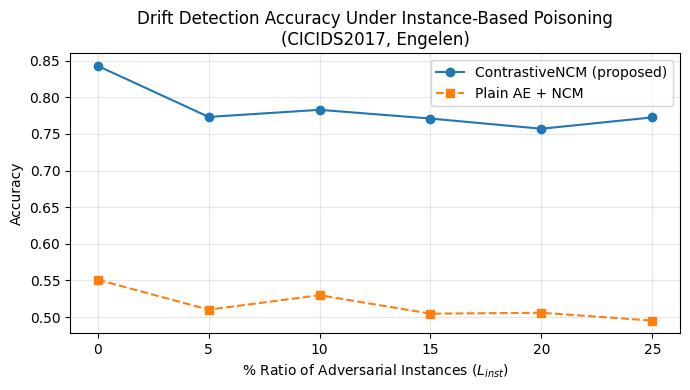

In [10]:
import matplotlib.pyplot as plt

pct_vals = [r['l_inst'] * 100 for r in results]

plot_cfg = {
    'ContrastiveNCM': dict(marker='o', ls='-', label='ContrastiveNCM (proposed)'),
    'Plain AE NCM': dict(marker='s', ls='--', label='Plain AE + NCM'),
}

plt.figure(figsize=(7, 4))
for m, style in plot_cfg.items():
    plt.plot(pct_vals, [r[m] for r in results], **style)

plt.xlabel('% Ratio of Adversarial Instances ($L_{inst}$)')
plt.ylabel('Accuracy')
plt.title('Drift Detection Accuracy Under Instance-Based Poisoning\n(CICIDS2017, Engelen)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
